##**CUNY SPS - DATA 620**


##**Brandon Chanderban**


##**Assignment 3: Graph Visualization**



##**Dataset Description:**

The objective of this assignment is to conduct an exploratory data analysis utilizing a dataset of my choosing, in conjunction with the NetworkX package within Python. For this task, I opted for the Dolphins social network dataset, which represents associations observed among a group of bottlenose dolphins (genus Tursiops).

Given that the utilized dataset represents a network, rather than examining the data as a conventional table of data, the dolphins shall instead be represented as nodes within the network, whilst the observed associations between them shall be represented as edges. As such, this network structure will allow us to ascertain and examine not only the dolphins themselves, but also the relationships existing between them and the broader structure that these relations give rise to.

Moreover, NetworkX will be used to construct and examine the network. Also, the analysis will endeavor to examine the network's connectivity, the relative importance of individual nodes, and the presence of subgroups within the network,

In the conduction of this data exploration, I intend to address questions such as the following:


*   What are the main structural characteristics observed within the network?
*   Which of the dolphins appear to occupy the most central or influential positions within the network?
*   Which nodes appear to function as linkers between different portions or subgroups of the network, and what do the network's pathways suggest about the potential movement of information/associations between the nodes?
*   Are there any apparent subgroups within the network?
*   How do the observed patterns within the visualized network compare against the calculated network measures? Do they appear in harmony, or are there discrepancies?



## **Data Import and Initial Exploration**

To commence the analysis, the required Python packages will first be imported and the Dolphins social network will be loaded directly from my GitHub repository. NetworkX will serve as the principal package for constructing and analyzing the network, whilst Matplotlib will subsequently be utilized in conjunction with NetworkX for the visualization of the network and its underlying structure.

In [1]:
# Import the required packages
import networkx as nx
import matplotlib.pyplot as plt
import requests
from io import StringIO

# Establish the raw GitHub URL for the Dolphins dataset
url = "https://raw.githubusercontent.com/bkchanderban/CUNY_SPS/refs/heads/main/DATA620/Assignment_3/out.dolphins"

# Retrieve the dataset directly from GitHub
response = requests.get(url)
response.raise_for_status()

# Load the edge list as an undirected NetworkX graph
G = nx.read_edgelist(
    StringIO(response.text),
    comments = '%',
    create_using=nx.Graph(),
    nodetype=int
    )

# Confirm that the graph was successfully created
print(G)

Graph with 62 nodes and 159 edges


## **Exploratory Data Analysis**

With the network successfully constructed, an initial exploratory analysis can now be conducted to ascertain its fundamental structural characteristics. As established during the data import process, the network consists of 62 nodes (bottlenose dolphins) and 159 edges (associations). The analysis will now extend beyond these initial counts to examine the network's density and connectivity, along with the number of connected components present.

Additionally, the degree of each node will be considered to provide an initial indication of how the associations are distributed throughout the network. These measures will in turn provide a foundation for the subsequent examination of node importance, the presence of subgroups, and even the potential pathways through the network.

In [21]:
# Calculate the basic structural characteristics of the network
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
is_connected = nx.is_connected(G)
num_components = nx.number_connected_components(G)

# Calculate the basic degree of each node
degrees = dict(G.degree())

# Calculate some basic degree statistics
average_degree = sum(degrees.values()) / num_nodes
maximum_degree = max(degrees.values())
minimum_degree = min(degrees.values())

# Display the  results
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Network density: {round(density, 4)}")
print(f"Fully connected: {is_connected}")
print(f"Number of connected components: {num_components}")
print(f"The average degree: {round(average_degree, 2)}")
print(f"The maximum degree: {maximum_degree}")
print(f"The minimum degree: {minimum_degree}")

Number of nodes: 62
Number of edges: 159
Network density: 0.0841
Fully connected: True
Number of connected components: 1
The average degree: 5.13
The maximum degree: 12
The minimum degree: 1


## **Initial Observations**

The exploratory analysis indicates that the network is fully connected and consists of a single connected component. As such, although not every dolphin possesses a direct association with every other dolphin, a pathway exists between every pair of nodes/dolphins within the network.

Moreover, the network has a density of approximately 0.0841, indicating that only about 8.41% of all possible pairwise associations are represented within the observed network. The dolphins possess an average degree of approximately 5.13, meaning that each dolphin is associated with approximately five other dolphins, on average. However, the degree values range from 1 to 12, suggesting that the extent of connectivity varies considerably among the dolphins. As such, this variation gives an initial indication that some nodes may occupy more structurally prominent positions than others.

## **Network Diameter and Average Shortest Path**

Given that the network was found to be connected, its diameter and shortest-path length may also be calculated. The diameter represents the greatest shortest-path distance existing between any two nodes, whilst the average shortest-path length provides an indication of the typical number of steps required to move between pairs of nodes within the network.

In [12]:
# Calculate the network diameter and the average shortest-path length
diameter = nx.diameter(G)
average_shortest_path = nx.average_shortest_path_length(G)

# Display the results
print(f"The diameter of the network is: {diameter}")
print(f"The average shortest-path length is: {round(average_shortest_path, 2)}")

The diameter of the network is: 8
The average shortest-path length is: 3.36


## **Initial Network Visualization**

NetworkX may now be utilized to visualize the relationships existing among the 62 dolphins. This initial visualization provides a graphical representation of the nodes and their observed associations prior to conducting a more detailed analysis of node centrality, linking nodes, and potential subgroups.

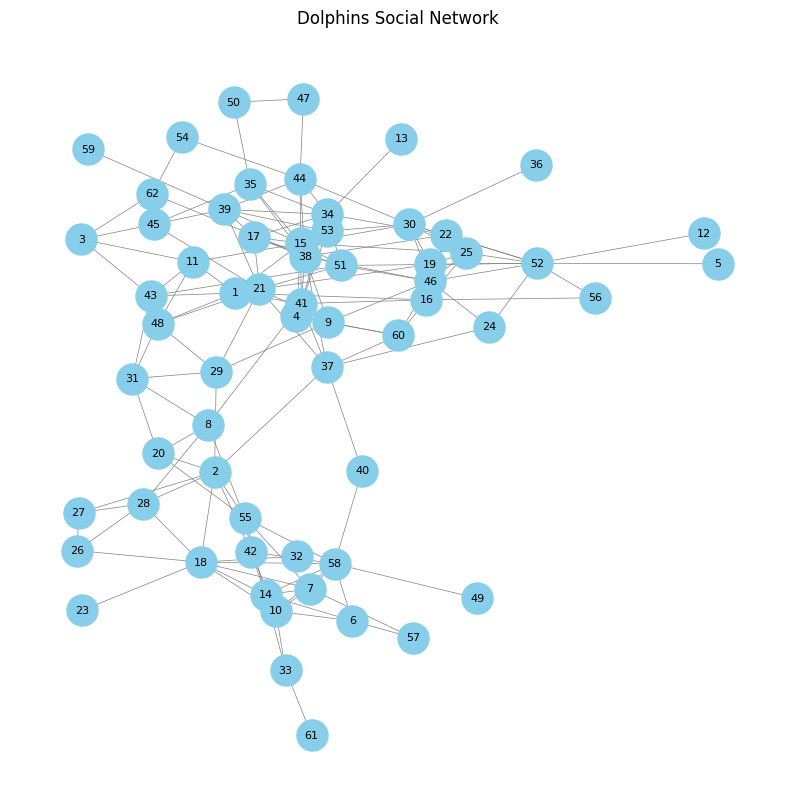

In [17]:
# Establish the positions of the nodes
pos = nx.spring_layout(G, seed = 6767)

# Create the initial network visualization
plt.figure(figsize = (10, 10))

nx.draw_networkx(
    G,
    pos = pos,
    with_labels = True,
    node_color = 'skyblue',
    node_size = 500,
    font_size = 8,
    edge_color = "gray",
    width = 0.5
)

plt.title("Dolphins Social Network")
plt.axis("off")
plt.show()

## **Node Importance and Linkers**

To further examine the structure of the network, betweenness centrality will be utilized in order to identify the nodes that frequently occur along the shortest paths between other nodes. Dolphins possessing relatively high betweenness centrality may in turn occupy positions within the network functioning as links between different portions of the network.

In [20]:
# Calculate the betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Identify the five nodes with the highest betweenness centrality
top_betweenness_nodes = sorted(
    betweenness.items(),
    key = lambda x: x[1],
    reverse = True
    )[:5]

# Display the results
print("The five nodes with the highest betweenness centrality are:")
for node, value in top_betweenness_nodes:
    print(f"Node {node}: {round(value, 3)}")

The five nodes with the highest betweenness centrality are:
Node 37: 0.248
Node 2: 0.213
Node 41: 0.143
Node 38: 0.139
Node 8: 0.118


The results above indicate that of the 62 nodes, Node 37 possesses the highest betweenness centrality (0.248), followed by Node 2 (0.213). As such, these nodes appear to occupy particularly important positions along the shortest paths connecting other dolphins and may therefore function as key linkers between different portions of the dolphin network.





## **Network Subgroups**

Finally, the network may be examined for the presence of potential subgroups or communities. For this purpose, NetworkX's greedy modularity community detection method will be utilized to group nodes that possess relatively stronger connections with one another. The identified communities may then be incorporated into the final visualization of the network.


In [24]:
# Identify communities within the network
communities = list(nx.community.greedy_modularity_communities(G))

# Display the number and members of the identified communities
print(f"The number of communities identified: {len(communities)}")

for i, community in enumerate(communities, start = 1):
    print(f"Community {i}'s Members: {sorted(community)}")

The number of communities identified: 4
Community 1's Members: [1, 3, 11, 13, 15, 17, 21, 34, 35, 38, 39, 41, 43, 44, 45, 47, 48, 50, 51, 53, 54, 59, 62]
Community 2's Members: [2, 6, 7, 8, 10, 14, 18, 20, 23, 26, 27, 28, 29, 31, 32, 33, 42, 49, 55, 57, 58, 61]
Community 3's Members: [4, 5, 9, 12, 16, 19, 22, 24, 25, 30, 36, 46, 52, 56, 60]
Community 4's Members: [37, 40]


## **Community Visualization**

To provide a more lucid representation of the identified subgroups, the network will now be visualized according to its four detected communities. The same node positions utilized within the initial network visualization will be retained, allowing the subgroup structure to be more readily compared against the original network.

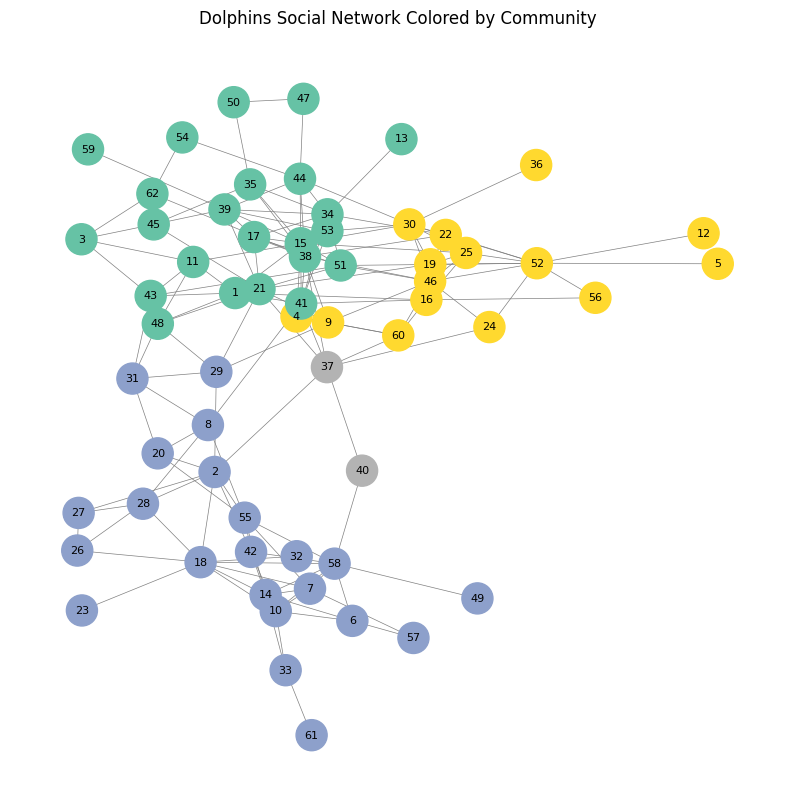

In [26]:
# Assign each of the dolphin nodes a value according to its identified community
community_colors = {}

for i, community in enumerate(communities):
  for node in community:
    community_colors[node] = i

# Create a list of community values corresponding to each node
node_colors = [community_colors[node] for node in G.nodes()]

# Visualize the network according to the identified communities
plt.figure(figsize=(10,10))

nx.draw_networkx(
    G,
    pos = pos,
    with_labels = True,
    node_color = node_colors,
    node_size = 500,
    font_size = 8,
    edge_color = "gray",
    width = 0.5,
    cmap = plt.cm.Set2
)

plt.title("Dolphins Social Network Colored by Community")
plt.axis("off")
plt.show()

The community analysis identified four distinct subgroups within the dolphin network, which may be more readily observed within the color-coded visualization above. Whilst the majority of the dolphins are distributed among the larger communities, Nodes 37 and 40 form a considerably smaller fourth subgroup. Interestingly enough, Node 37 was previously found to possess the highest betweenness centrality within the network. Consequently, its position within the visualization (almost huddled at the center of the other subgroups), coupled with its relatively high betweenness centrality, further suggests that this node may serve an important linking function between differing portions of the dolphin network (a particularly associated dolphin indeed).


## **Conclusion**

Through the utilization of Python and NetworkX, this analysis provided insight into the structure and connectivity of the Dolphins social network. The network was found to contain 62 nodes and 159 edges and, despite its relatively low density, all nodes were connected through a single component. Moreover, the analysis identified Node 37 as possessing the highest betweenness centrality, whilst community detection revealed four apparent subgroups within the network.

In essence, the analysis demonstrated how network measures and visualizations may be drawn upon in conjunction to better comprehend not only the relationships existing among individual nodes, but also the broader structure arising from these relationships.

## **Reference**
KONECT. (n.d.). *Dolphins*. Koblenz Network Collection.


http://konect.cc/networks/dolphins/